# Notebook 2 — Reduction et Selection de Dimensions

**Methodes utilisees :**
- Analyse en Composantes Principales (PCA)
- Importance des attributs par Random Forest (SelectFromModel)
- Selection univariee par Chi2 / ANOVA F-score

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
from pathlib import Path
import json

ROOT = Path('..').resolve()
DATA_PROC = ROOT / 'data' / 'processed'

X = pd.read_parquet(DATA_PROC / 'X_preprocessed.parquet')
y_df = pd.read_parquet(DATA_PROC / 'y_preprocessed.parquet')
y = y_df['FLAG_RESILIATION'].astype(int)

print(f"X : {X.shape},  y : {y.shape}")
print(f"Classes : {y.value_counts().to_dict()}")

X : (46842, 57),  y : (46842,)
Classes : {0: 38438, 1: 8404}


## 2.1 Importance des attributs par Random Forest

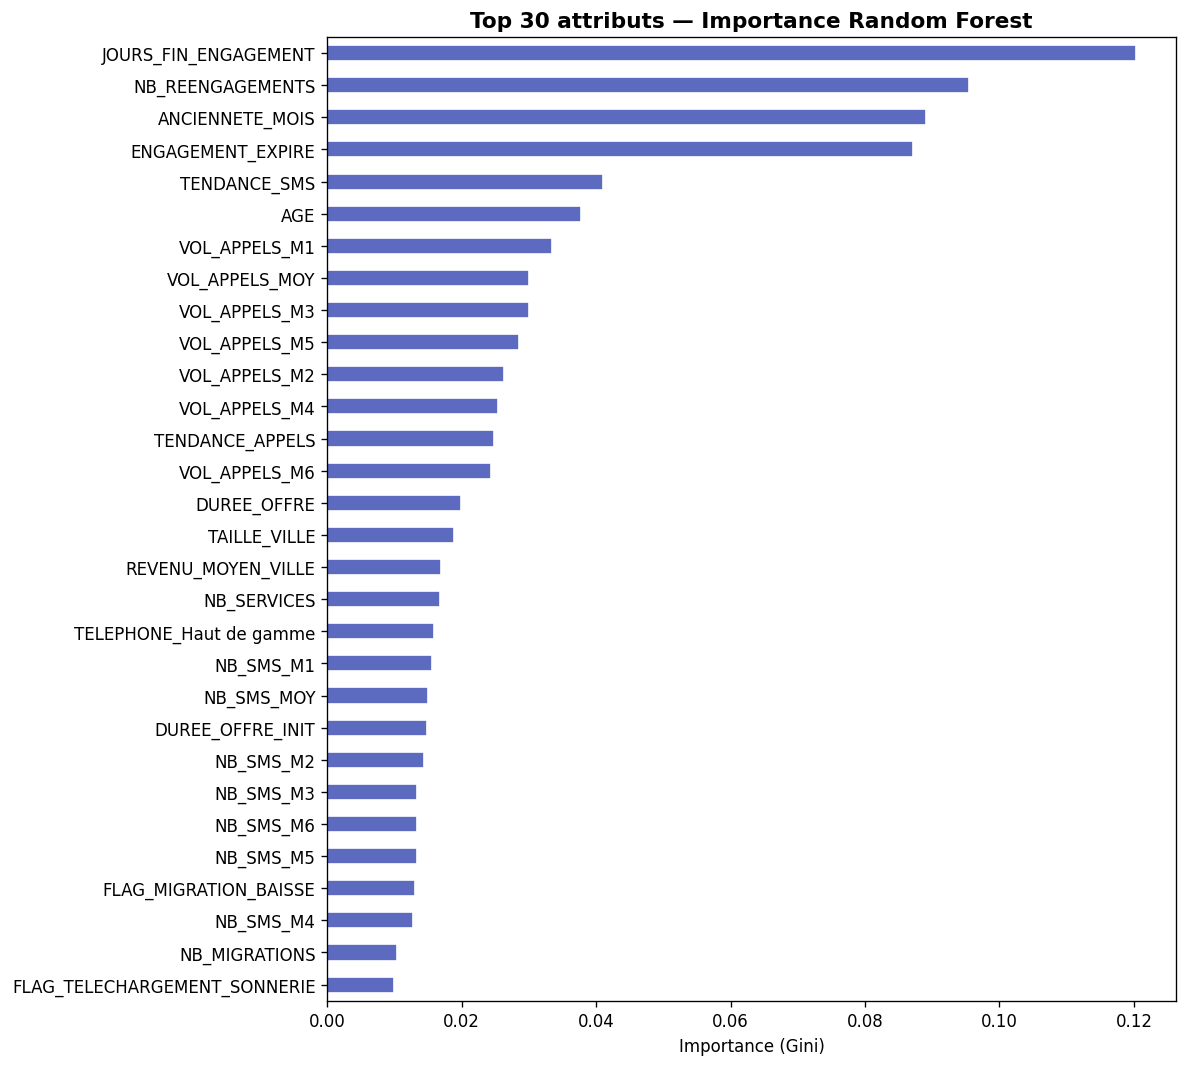

Top 10 attributs :
JOURS_FIN_ENGAGEMENT    0.120245
NB_REENGAGEMENTS        0.095488
ANCIENNETE_MOIS         0.089002
ENGAGEMENT_EXPIRE       0.087148
TENDANCE_SMS            0.041012
AGE                     0.037778
VOL_APPELS_M1           0.033492
VOL_APPELS_MOY          0.030029
VOL_APPELS_M3           0.030013
VOL_APPELS_M5           0.028508


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_selector = RandomForestClassifier(
    n_estimators=200, max_depth=12,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_selector.fit(X_train, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Top 30
fig, ax = plt.subplots(figsize=(10, 9))
importances.head(30).sort_values().plot.barh(ax=ax, color='#5C6BC0', edgecolor='white')
ax.set_title('Top 30 attributs — Importance Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'importance_rf.png', bbox_inches='tight')
plt.show()

print(f"Top 10 attributs :")
print(importances.head(10).to_string())

## 2.2 Selection des attributs (seuil importance)

Attributs pour 95% d'importance cumulee : 35 / 57


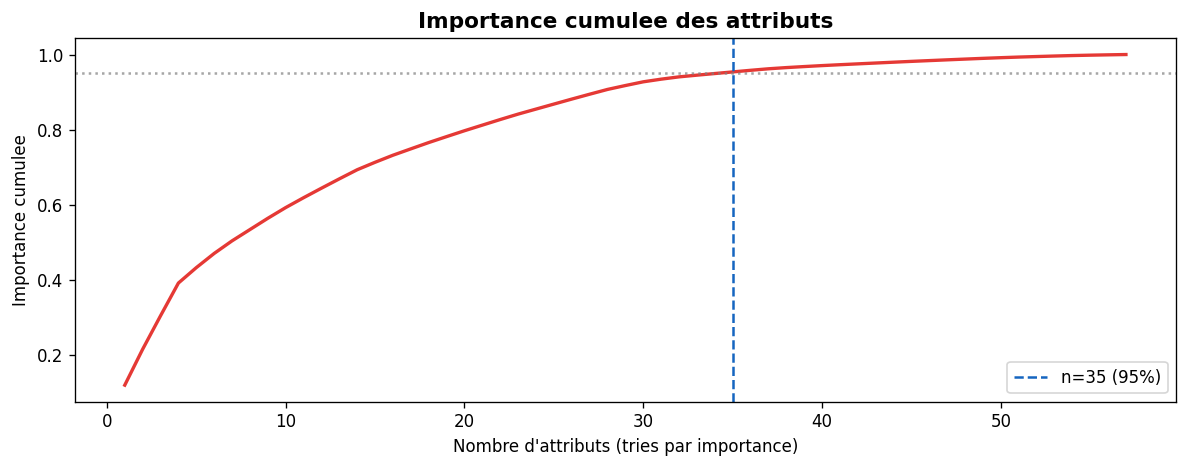

In [3]:
# Seuil : conserver les attributs dont l'importance cumulee atteint 95%
cum_importance = importances.cumsum()
n_features_95 = (cum_importance < 0.95).sum() + 1
print(f"Attributs pour 95% d'importance cumulee : {n_features_95} / {len(importances)}")

selected_features = importances.head(n_features_95).index.tolist()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cum_importance)+1), cum_importance.values, color='#E53935', linewidth=2)
ax.axvline(n_features_95, color='#1565C0', linestyle='--', label=f'n={n_features_95} (95%)')
ax.axhline(0.95, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel("Nombre d'attributs (tries par importance)")
ax.set_ylabel('Importance cumulee')
ax.set_title('Importance cumulee des attributs', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'importance_cumulee.png', bbox_inches='tight')
plt.show()

## 2.3 Analyse en Composantes Principales (PCA)

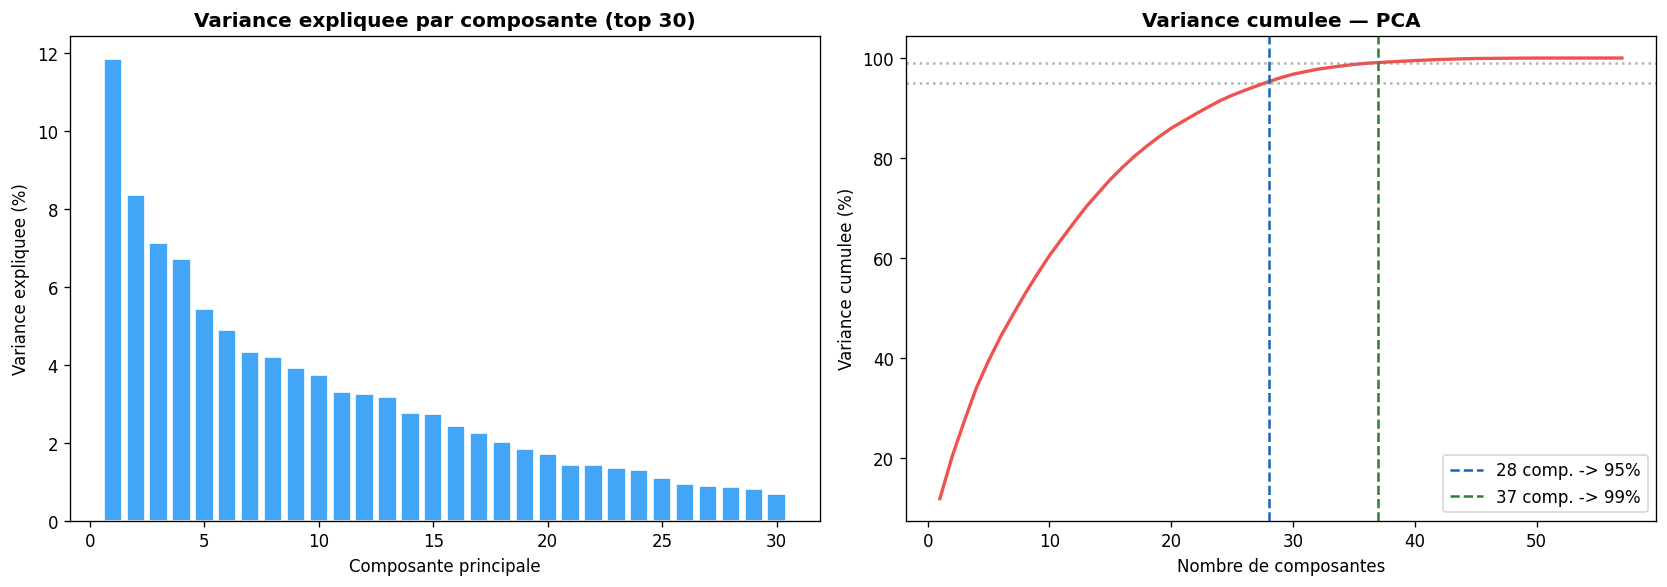

Composantes pour 95% de variance : 28
Composantes pour 99% de variance : 37


In [4]:
from sklearn.decomposition import PCA

# PCA sur le jeu complet
pca_full = PCA(random_state=42)
pca_full.fit(X)

# Variance expliquee
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)
n_comp_95 = np.argmax(cum_var >= 0.95) + 1
n_comp_99 = np.argmax(cum_var >= 0.99) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, min(31, len(exp_var)+1)), exp_var[:30] * 100,
            color='#42A5F5', edgecolor='white')
axes[0].set_title('Variance expliquee par composante (top 30)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquee (%)')

axes[1].plot(range(1, len(cum_var)+1), cum_var * 100, color='#EF5350', linewidth=2)
axes[1].axvline(n_comp_95, color='#1565C0', linestyle='--',
                label=f'{n_comp_95} comp. -> 95%')
axes[1].axvline(n_comp_99, color='#2E7D32', linestyle='--',
                label=f'{n_comp_99} comp. -> 99%')
axes[1].axhline(95, color='gray', linestyle=':', alpha=0.6)
axes[1].axhline(99, color='gray', linestyle=':', alpha=0.6)
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulee (%)')
axes[1].set_title('Variance cumulee — PCA', fontsize=12, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'pca_variance.png', bbox_inches='tight')
plt.show()

print(f"Composantes pour 95% de variance : {n_comp_95}")
print(f"Composantes pour 99% de variance : {n_comp_99}")

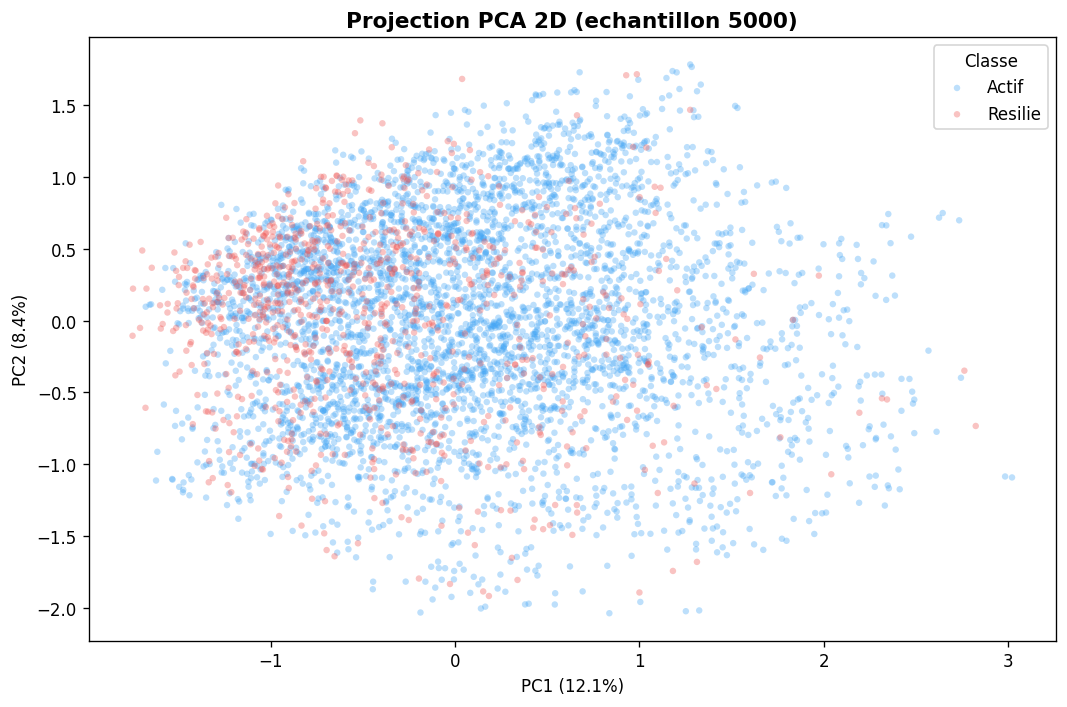

In [5]:
# Visualisation 2D PCA (sample)
from sklearn.decomposition import PCA as PCA2D

pca2 = PCA2D(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X.sample(5000, random_state=42))
y_sample = y.loc[X.sample(5000, random_state=42).index]

fig, ax = plt.subplots(figsize=(9, 6))
colors = {0: '#42A5F5', 1: '#EF5350'}
labels = {0: 'Actif', 1: 'Resilie'}
for cls in [0, 1]:
    mask = y_sample == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[cls], label=labels[cls],
               alpha=0.35, s=15, edgecolors='none')
ax.set_title('Projection PCA 2D (echantillon 5000)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(title='Classe', framealpha=0.8)
plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'pca_2d.png', bbox_inches='tight')
plt.show()

## 2.4 Sauvegarde des attributs selectionnes

In [6]:
import joblib

# PCA pour 95% de variance — utilise dans la modelisation
pca_95 = PCA(n_components=n_comp_95, random_state=42)
pca_95.fit(X[selected_features])

joblib.dump(pca_95,          ROOT / 'models' / 'pca.pkl')
joblib.dump(selected_features, ROOT / 'models' / 'selected_features.pkl')

with open(DATA_PROC / 'selected_features.json', 'w') as f:
    json.dump(selected_features, f, indent=2)

print(f"Attributs selectionnes : {len(selected_features)}")
print(f"Composantes PCA retenues : {n_comp_95}")
print("Fichiers sauvegardes : models/pca.pkl, models/selected_features.pkl")

# Resume
print("\n=== Resume de la reduction de dimension ===")
print(f"Dimensions initiales    : {X.shape[1]} attributs")
print(f"Apres selection RF      : {len(selected_features)} attributs (-{X.shape[1]-len(selected_features)})")
print(f"Apres PCA (95% var.)    : {n_comp_95} composantes")
print(f"Reduction totale        : {100*(1 - n_comp_95/X.shape[1]):.1f}%")

Attributs selectionnes : 35
Composantes PCA retenues : 28
Fichiers sauvegardes : models/pca.pkl, models/selected_features.pkl

=== Resume de la reduction de dimension ===
Dimensions initiales    : 57 attributs
Apres selection RF      : 35 attributs (-22)
Apres PCA (95% var.)    : 28 composantes
Reduction totale        : 50.9%
